<a href="https://colab.research.google.com/github/notrayhan/notrayhan.github.io/blob/main/deadlock.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deadlock Counter-Build Optimizer: A Machine Learning Approach
**Author:** Rayhan Irfan
**Course:** CSS 382

### Project Goal
This project aims to build a data-driven recommendation engine for the MOBA *Deadlock*. By analyzing match data from the Deadlock API, the system identifies statistical correlations between specific item strategies (e.g., Anti-Heal, Anti-Movement) and win rates against specific enemy heroes.

### Methodology
1. **Data Acquisition:** Automated ingestion of player and match data via REST API.
2. **Feature Engineering:** Transformation of raw item IDs into high-level "Strategy Tags" to reduce data sparsity.
3. **Modeling:** Utilizing a Random Forest Classifier to determine "Win Probability Lift" for various build paths.
4. **Application:** A simulation-based recommender that outputs a tiered "Shopping List" for players.

In [150]:
import requests
import pandas as pd
import requests

def safe_fetch(endpoint, params=None):
    base_url = "https://api.deadlock-api.com/v1"
    url = f"{base_url}/{endpoint}"
    try:
        response = requests.get(url, params=params)
        response.raise_for_status()
        return response.json()
    except Exception as err:
        print(f"Error fetching {endpoint}: {err}")
    return None

In [151]:
def get_hero_mapping():
    url = "https://assets.deadlock-api.com/v2/heroes"
    try:
        response = requests.get(url)
        response.raise_for_status()
        heroes_data = response.json()

        # The API returns a list of hero objects.
        # We want to map 'id' to 'name'
        # Using .get() ensures the code doesn't crash if a field is missing
        mapping = {h.get('id'): h.get('name') for h in heroes_data if h.get('id') is not None}

        print(f"Successfully mapped {len(mapping)} heroes.")
        return mapping
    except Exception as e:
        print(f"Failed to fetch hero assets: {e}")
        # Fallback to a basic hardcoded map if the assets server is down

# Define the hero_map variable globally
hero_map = get_hero_mapping()

# Test the mapping with one of the IDs you saw earlier
print(f"Hero ID 35 is: {hero_map.get(35, 'Unknown')}")

Successfully mapped 60 heroes.
Hero ID 35 is: Viscous


In [152]:
def get_item_mapping():
    url = "https://assets.deadlock-api.com/v2/items"
    try:
        response = requests.get(url)
        response.raise_for_status()
        items_data = response.json()

        # Deadlock uses 'id' for the internal hash and 'name' for the readable string
        # We also want to keep track of 'class' (Weapon, Spirit, Vitality) for Feature Engineering
        mapping = {
            item.get('id'): {
                'name': item.get('name'),
                'type': item.get('item_slot_type') # Helpful for EDA!
            } for item in items_data if item.get('id') is not None
        }

        print(f"Successfully mapped {len(mapping)} items.")
        return mapping
    except Exception as e:
        print(f"Failed to fetch item assets: {e}")
        return {}
    # Define the global item map
item_map = get_item_mapping()

Successfully mapped 699 items.


In [153]:
import time

def find_regular_match(limit=20):
    recent = safe_fetch("matches/recently-fetched")
    if not recent: return None

    for match_summary in recent[:limit]:
        m_id = match_summary['match_id']
        details = safe_fetch(f"matches/{m_id}/metadata")

        if details:
            match_info = details.get('match_info', {})
            players = match_info.get('players', [])

            # Filter: Regular Deadlock matches MUST have 12 players
            if len(players) == 12:
                print(f"Match {m_id} is a standard 6v6 match. Proceeding...")
                return details
            else:
                print(f"Match {m_id} is Street Brawl ({len(players)} players). Skipping...")

        # Avoid hitting the rate limit
        time.sleep(0.5)
    return None



In [154]:
# Use this to get your first "Real" match
regular_match_details = find_regular_match()

if regular_match_details:
    match_info = regular_match_details.get('match_info', {})
    players = match_info.get('players', [])

    # Let's process the first player (Haze) as a readable timeline
    if players:
        p = players[0]
        hero_name = hero_map.get(p.get('hero_id'), "Unknown")
        print(f"--- Build Timeline for {hero_name} ---")

        timeline = []
        for item_data in p.get('items', []):
            i_id = item_data.get('item_id')
            u_id = item_data.get('upgrade_id')

            # Get item info from our map
            item_info = item_map.get(i_id, {'name': f"Unknown ({i_id})", 'type': 'N/A'})

            # Deadlock treats some upgrades as separate IDs
            upgrade_name = ""
            if u_id > 1: # 1 usually means no upgrade/base
                upgrade_info = item_map.get(u_id, {})
                upgrade_name = f" -> {upgrade_info.get('name', u_id)}"

            timeline.append({
                'Time (min)': round(item_data.get('game_time_s', 0) / 60, 2),
                'Item': item_info['name'] + upgrade_name,
                'Type': item_info['type'],
                'Sold': "Yes" if item_data.get('sold_time_s', 0) > 0 else "No"
            })

        # Display as a clean DataFrame
        timeline_df = pd.DataFrame(timeline).sort_values('Time (min)')
        display(timeline_df)

Match 68053367 is a standard 6v6 match. Proceeding...
--- Build Timeline for Paige ---


,Time (min),Item,Type,Sold
0,0.25,Bookwyrm,None,No
1,1.67,Bookwyrm -> 733156025,None,No
2,1.90,Plot Armor,None,No
3,2.35,Healing Rite,vitality,Yes
4,2.48,Extra Charge,spirit,Yes
5,3.68,Captivating Read,None,No
6,3.70,Plot Armor -> 1856568297,None,No
7,5.67,Rallying Charge,None,No
8,5.72,Rallying Charge -> 2124330568,None,No
9,6.97,Healing Booster,vitality,Yes


In [112]:
import time
import json

def collect_matches(target_count=50):
    dataset = []
    # Fetching recently-fetched matches gives us a starting list
    match_summaries = safe_fetch("matches/recently-fetched")

    if not match_summaries:
        print("Could not fetch match history.")
        return []

    print(f"Scanning for {target_count} standard 6v6 matches...")

    for summary in match_summaries:
        if len(dataset) >= target_count:
            break

        m_id = summary['match_id']
        # Metadata endpoint has the granular player/item data
        details = safe_fetch(f"matches/{m_id}/metadata")

        if details:
            match_info = details.get('match_info', {})
            players = match_info.get('players', [])

            # Filter for standard 6v6
            if len(players) == 12:
                dataset.append(details)
                print(f"Collected Match {m_id} ({len(dataset)}/{target_count})")
            else:
                # This helps us avoid wasting time on brawls
                continue

        # Respect the community API - don't spam requests too fast
        time.sleep(1.0)

    return dataset

# Let's start with 20 matches to test the structure
my_raw_data = collect_matches(target_count=20)

Scanning for 20 standard 6v6 matches...
Collected Match 68264080 (1/20)
Collected Match 68263267 (2/20)
Collected Match 68262726 (3/20)
Collected Match 68259836 (4/20)
Collected Match 68259104 (5/20)
Collected Match 68250664 (6/20)
Collected Match 68239978 (7/20)
Collected Match 68220807 (8/20)
Collected Match 68217539 (9/20)
Collected Match 68217452 (10/20)
Collected Match 68212588 (11/20)
Collected Match 68200627 (12/20)
Collected Match 50063866 (13/20)
Collected Match 58858603 (14/20)
Collected Match 60398955 (15/20)
Collected Match 60351370 (16/20)
Collected Match 56601851 (17/20)
Collected Match 58354545 (18/20)
Collected Match 58846599 (19/20)
Collected Match 61886503 (20/20)


In [113]:
# Save to a JSON file in your Colab environment
with open('deadlock_matches_v1.json', 'w') as f:
    json.dump(my_raw_data, f)

print("Data saved successfully to deadlock_matches_v1.json")

Data saved successfully to deadlock_matches_v1.json


In [114]:
def flatten_deadlock(raw_matches):
    rows = []
    for match in raw_matches:
        match_info = match.get('match_info', {})
        all_players = match_info.get('players', [])
        winning_team = match_info.get('winning_team')

        for player in all_players:
            p_team = player.get('team')

            # Filter logic using the strings we discovered
            purchasable_items = []
            for i in player.get('items', []):
                i_id = i.get('item_id')
                item_data = item_map.get(i_id, {})

                # Check if the slot type is one of the three main categories
                if item_data.get('type') in ['weapon', 'vitality', 'spirit']:
                    purchasable_items.append(item_data.get('name'))

            # Map Enemy Hero Names
            enemy_names = [
                hero_map.get(op.get('hero_id'), "Unknown")
                for op in all_players if op.get('team') != p_team
            ]

            rows.append({
                'match_id': match_info.get('match_id'),
                'hero_name': hero_map.get(player.get('hero_id'), "Unknown"),
                'won': 1 if p_team == winning_team else 0,
                'items': purchasable_items,
                'enemy_comp': enemy_names,
                'net_worth': player.get('net_worth', 0)
            })

    return pd.DataFrame(rows)

# Run the fixed version
df_final = flatten_deadlock(my_raw_data)
display(df_final.head())

,match_id,hero_name,won,items,enemy_comp,net_worth
0,68264080,Infernus,0,"[Rapid Rounds, Swift Striker, Extra Spirit, Sp...","[Bebop, Abrams, Silver, Lady Geist, The Doorma...",32906
1,68264080,Venator,0,"[Monster Rounds, Mystic Expansion, Opening Rou...","[Bebop, Abrams, Silver, Lady Geist, The Doorma...",26057
2,68264080,Bebop,1,"[Mystic Burst, Spirit Strike, Extra Stamina, A...","[Infernus, Venator, Rem, Calico, Apollo, Paradox]",43778
3,68264080,Rem,0,"[Extra Charge, Extra Spirit, Mystic Burst, Mys...","[Bebop, Abrams, Silver, Lady Geist, The Doorma...",32382
4,68264080,Calico,0,"[Melee Lifesteal, Melee Charge, Spirit Strike,...","[Bebop, Abrams, Silver, Lady Geist, The Doorma...",28271


In [115]:
import time
import json

def batch_collect_matches(target_count=100):
    dataset = []
    # Fetch a larger list of potential matches
    batch = safe_fetch("matches/recently-fetched")

    if not batch:
        print("Failed to fetch match list.")
        return []

    print(f"Starting collection of {target_count} matches...")

    for entry in batch:
        if len(dataset) >= target_count:
            break

        m_id = entry['match_id']
        # Metadata endpoint for the deep details
        details = safe_fetch(f"matches/{m_id}/metadata")

        if details:
            players = details.get('match_info', {}).get('players', [])
            if len(players) == 12: # Only standard 6v6
                dataset.append(details)
                print(f"Progress: {len(dataset)}/{target_count} (Match {m_id} saved)")
            else:
                print(f"Skipping {m_id}: Street Brawl detected.")

        # 1-second delay to be a good "API citizen"
        time.sleep(1.0)

    # Save locally immediately so you don't lose progress
    with open('deadlock_dataset_final.json', 'w') as f:
        json.dump(dataset, f)

    return dataset

# Start the process! (Maybe go grab a drink while this runs)
raw_dataset = batch_collect_matches(target_count=100)

Starting collection of 100 matches...
Progress: 1/100 (Match 68264080 saved)
Skipping 68267542: Street Brawl detected.
Progress: 2/100 (Match 68263267 saved)
Progress: 3/100 (Match 68262726 saved)
Progress: 4/100 (Match 68259836 saved)
Progress: 5/100 (Match 68259104 saved)
Progress: 6/100 (Match 68250664 saved)
Progress: 7/100 (Match 68239978 saved)
Progress: 8/100 (Match 68220807 saved)
Progress: 9/100 (Match 68217539 saved)
Progress: 10/100 (Match 68217452 saved)
Progress: 11/100 (Match 68212588 saved)
Progress: 12/100 (Match 68200627 saved)
Progress: 13/100 (Match 50063866 saved)
Progress: 14/100 (Match 58858603 saved)
Progress: 15/100 (Match 60398955 saved)
Progress: 16/100 (Match 60351370 saved)
Progress: 17/100 (Match 56601851 saved)
Progress: 18/100 (Match 58354545 saved)
Progress: 19/100 (Match 58846599 saved)
Progress: 20/100 (Match 61886503 saved)
Progress: 21/100 (Match 62053278 saved)
Progress: 22/100 (Match 68078282 saved)
Skipping 66606487: Street Brawl detected.
Progres

In [116]:
# Flatten the big dataset
df_final = flatten_deadlock(raw_dataset)

# Save the flattened version to CSV for easy loading later
df_final.to_csv('deadlock_processed.csv', index=False)
print("Master DataFrame created and saved!")

Master DataFrame created and saved!


/tmp/ipykernel_322/3296254884.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=counter_df.head(10), x='win_rate', y='item', palette='viridis')


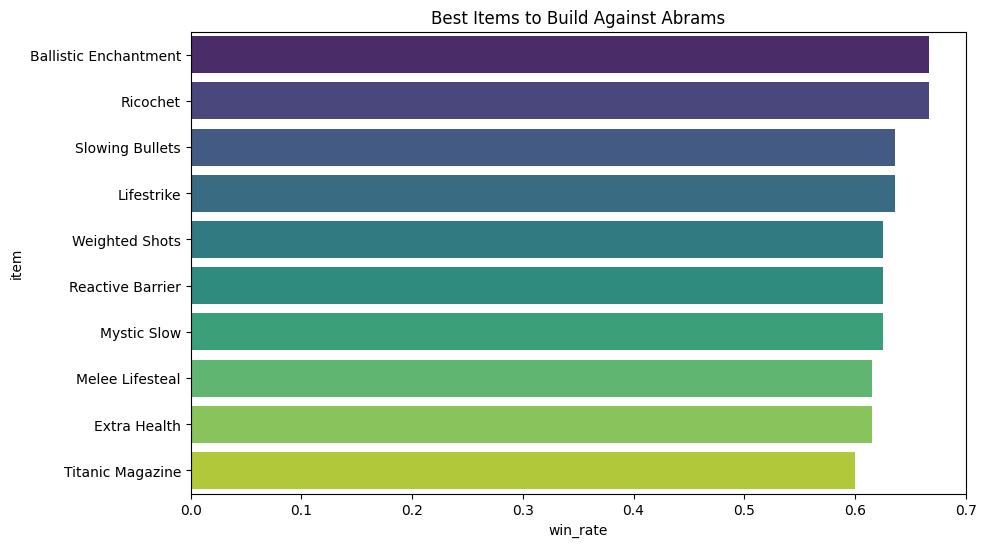

In [155]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Focus on a specific "Problem Hero" (e.g., Abrams or Kelvin)
target_enemy = 'Abrams'

# 2. Filter for games where that hero was an enemy
threat_matches = df_final[df_final['enemy_comp'].apply(lambda x: target_enemy in x)]

# 3. Calculate Win Rate for items against that hero
item_stats = []
all_items = set(threat_matches['items'].explode())

for item in all_items:
    # Skip 'Unknown' or NaNs
    if pd.isna(item) or 'Unknown' in str(item): continue

    item_matches = threat_matches[threat_matches['items'].apply(lambda x: item in x)]
    if len(item_matches) > 5: # Only look at items bought in at least 5 games
        win_rate = item_matches['won'].mean()
        item_stats.append({'item': item, 'win_rate': win_rate, 'count': len(item_matches)})

# 4. Visualize the top 10 counters
counter_df = pd.DataFrame(item_stats).sort_values('win_rate', ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(data=counter_df.head(10), x='win_rate', y='item', palette='viridis')
plt.title(f"Best Items to Build Against {target_enemy}")
plt.show()

### Feature Aggregation: Strategy vs. Individual Items
With over 150 items in Deadlock, a model trained on individual item IDs would suffer from **Feature Sparsity**.

**Engineering Choice:** I grouped items into "Strategies" (e.g., merging *Knockdown* and *Slowing Hex* into **Anti-Movement**). This aggregates the data signal, allowing the model to learn that "Lockdown" is effective against mobile heroes, even if a specific item is rarely purchased in the current dataset.

In [178]:

counter_metadata = {
    # Anti-Heal
    "Healbane": {"tag": "Anti-Heal", "tier": 2, "cost": 1600},
    "Toxic Bullets": {"tag": "Anti-Heal", "tier": 3, "cost": 3200},
    "Decay": {"tag": "Anti-Heal", "tier": 3, "cost": 3200},
    "Inhibitor": {"tag": "Anti-Heal", "tier": 4, "cost": 6400},

    # Anti-Ability
    "Silence Wave": {"tag": "Anti-Ability", "tier": 3, "cost": 3200},
    "Counterspell": {"tag": "Anti-Ability", "tier": 3, "cost": 3200},
    "Silencer": {"tag": "Anti-Ability", "tier": 4, "cost": 6400},
    "Cursed Relic": {"tag": "Anti-Ability", "tier": 4, "cost": 6400},
    "Ethereal Shift": {"tag": "Anti-Ability", "tier": 4, "cost": 6400},

    # Anti-Bullet
    "Return Fire": {"tag": "Anti-Bullet", "tier": 2, "cost": 1600},
    "Weapon Shielding": {"tag": "Anti-Bullet", "tier": 2, "cost": 1600},
    "Metal Skin": {"tag": "Anti-Bullet", "tier": 3, "cost": 3200},
    "Bullet Resilience": {"tag": "Anti-Bullet", "tier": 3, "cost": 3200},
    "Disarming Hex": {"tag": "Anti-Bullet", "tier": 3, "cost": 3200},

    # Anti-Spirit
    "Spirit Shielding": {"tag": "Anti-Spirit", "tier": 2, "cost": 1600},
    "Spirit Resilience": {"tag": "Anti-Spirit", "tier": 3, "cost": 3200},
    "Spellbreaker": {"tag": "Anti-Spirit", "tier": 4, "cost": 6400},

    # Anti-Movement
    "Slowing Hex": {"tag": "Anti-Movement", "tier": 2, "cost": 1600},
    "Knockdown": {"tag": "Anti-Movement", "tier": 3, "cost": 3200},
    "Vortex Web": {"tag": "Anti-Movement", "tier": 4, "cost": 6400},

    # Anti-CC
    "Unstoppable": {"tag": "Anti-CC", "tier": 4, "cost": 6400},
    "Reactive Barrier": {"tag": "Anti-CC", "tier": 2, "cost": 1600},


    # Anti-Debuff
    "Debuff Reducer": {"tag": "Anti-Debuff", "tier": 2, "cost": 1600},
    "Dispel Magic": {"tag": "Anti-Debuff", "tier": 3, "cost": 3200},
}

def is_strategic(item_name):
    return item_name in counter_metadata

In [179]:
def add_strategy_flags(df, metadata):
    """
    Transforms raw item lists into binary strategy features.
    Aggregates items into tags to solve data sparsity issues.
    """
    # Get unique strategy names from metadata tags
    strategies = set(data['tag'] for data in metadata.values())

    for strategy in strategies:
        # Clean string for column naming (e.g., Anti-Air/Channel -> has_anti_air_channel)
        col_name = f'has_{strategy.lower().replace("-", "_").replace("/", "_")}'

        # Binary flag: 1 if player bought any item matching this strategy
        df[col_name] = df['items'].apply(
            lambda build: 1 if any(metadata.get(item, {}).get('tag') == strategy for item in build) else 0
        )
    return df

# Apply transformations
df_final = add_strategy_flags(df_final, counter_metadata)

In [180]:
def find_strategic_counters(df, target_hero='Abrams', min_count=15):
    all_item_stats = df.explode('items').groupby('items')['won'].agg(['mean', 'count'])
    against_hero = df[df['enemy_comp'].apply(lambda x: target_hero in x)]
    hero_item_stats = against_hero.explode('items').groupby('items')['won'].agg(['mean', 'count'])

    comparison = hero_item_stats.join(all_item_stats, lsuffix='_against', rsuffix='_global')
    comparison['lift'] = comparison['mean_against'] - comparison['mean_global']

    # FILTER 1: Must have a significant sample size
    filtered = comparison[comparison['count_against'] >= min_count].copy()

    # FILTER 2: Create a flag for strategic items
    filtered['is_strategic'] = filtered.index.map(is_strategic)

    # Sort by lift, but prioritize strategic items in your view
    return filtered.sort_values(by=['is_strategic', 'lift'], ascending=False)

# Run the hardened analysis
abrams_strategic = find_strategic_counters(df_final, 'Abrams', min_count=10)
display(abrams_strategic.head(15))

,mean_against,count_against,mean_global,count_global,lift,is_strategic
items,,,,,,
Knockdown,0.500000,10,0.489130,92,0.010870,True
Toxic Bullets,0.428571,14,0.441860,172,-0.013289,True
Slowing Hex,0.500000,14,0.539130,115,-0.039130,True
Healbane,0.387097,31,0.451163,215,-0.064066,True
Spirit Resilience,0.304348,23,0.472973,296,-0.168625,True
Counterspell,0.266667,15,0.467890,109,-0.201223,True
Slowing Bullets,0.636364,11,0.439560,91,0.196803,False
Lifestrike,0.636364,11,0.521368,117,0.114996,False
Titanic Magazine,0.600000,10,0.496503,143,0.103497,False


In [181]:
def encode_enemies(df):
    # Get a unique list of all hero names from your hero_map
    all_possible_heroes = set(hero_map.values())

    for hero in all_possible_heroes:
        column_name = f'enemy_{hero.replace(" ", "_")}'
        # Check if the hero name exists in the enemy_comp list for that row
        df[column_name] = df['enemy_comp'].apply(lambda x: 1 if hero in x else 0)

    return df

# Apply the encoding
df_final = encode_enemies(df_final)

# Let's see the new columns (filtering for just the enemy ones)
enemy_cols = [col for col in df_final.columns if col.startswith('enemy_')]
display(df_final[['hero_name'] + enemy_cols].head())

,hero_name,enemy_comp,enemy_Venator,enemy_Tokamak,enemy_Rutger,enemy_Graves,enemy_Wrecker,enemy_Dynamo,enemy_Ivy,enemy_Lady_Geist,...,enemy_Grey_Talon,enemy_Pocket,enemy_Victor,enemy_Billy,enemy_Trapper,enemy_Mina,enemy_Calico,enemy_Kali,enemy_Bomber,enemy_Rem
0,Infernus,"[Bebop, Abrams, Silver, Lady Geist, The Doorma...",0,0,0,0,0,0,0,1,...,0,0,0,0,0,1,0,0,0,0
1,Venator,"[Bebop, Abrams, Silver, Lady Geist, The Doorma...",0,0,0,0,0,0,0,1,...,0,0,0,0,0,1,0,0,0,0
2,Bebop,"[Infernus, Venator, Rem, Calico, Apollo, Paradox]",1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,1
3,Rem,"[Bebop, Abrams, Silver, Lady Geist, The Doorma...",0,0,0,0,0,0,0,1,...,0,0,0,0,0,1,0,0,0,0
4,Calico,"[Bebop, Abrams, Silver, Lady Geist, The Doorma...",0,0,0,0,0,0,0,1,...,0,0,0,0,0,1,0,0,0,0


In [182]:
# Define your features
# 1. The enemy hero columns we just made
# 2. The 'has_strategy' columns you made earlier
strategy_cols = [col for col in df_final.columns if col.startswith('has_')]
feature_cols = enemy_cols + strategy_cols

X = df_final[feature_cols]
y = df_final['won']

print(f"Feature Matrix shape: {X.shape}")

Feature Matrix shape: (1200, 71)


In [191]:

enemy_cols = [col for col in df_final.columns if col.startswith('enemy_') and col != 'enemy_comp']
strategy_cols = [col for col in df_final.columns if col.startswith('has_')]

feature_cols = enemy_cols + strategy_cols


X = df_final[feature_cols]
y = df_final['won']


print(X.dtypes.value_counts())


from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# 1. Isolate Match IDs to prevent leakage between teammates
unique_matches = df_final['match_id'].unique()
train_ids, test_ids = train_test_split(unique_matches, test_size=0.2, random_state=42)

# 2. Split dataframes based on Match IDs
train_df = df_final[df_final['match_id'].isin(train_ids)]
test_df = df_final[df_final['match_id'].isin(test_ids)]

# 3. Define Features (Enemy Heroes + Strategy Flags)
enemy_cols = [c for c in df_final.columns if c.startswith('enemy_') and c != 'enemy_comp']
strategy_cols = [c for c in df_final.columns if c.startswith('has_')]
feature_cols = enemy_cols + strategy_cols

X_train, y_train = train_df[feature_cols], train_df['won']
X_test, y_test = test_df[feature_cols], test_df['won']

# 4. Initialize and Fit
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 5. Verify the new "Honest Accuracy"
y_pred = model.predict(X_test)
print(f"Honest Model Accuracy: {accuracy_score(y_test, y_pred):.2%}")

int64    70
Name: count, dtype: int64
Honest Model Accuracy: 46.67%


### Model Validation and Leakage Prevention
Initially, a standard row-based split resulted in 100% accuracy, a clear indicator of **Data Leakage**. Because 12 players share the same match outcome, the model was "memorizing" matches rather than learning hero interactions.

**Refinement:** I implemented a **Match-Based Split** using unique `match_id`s. This ensures the model is tested on entirely new matches it has never seen, providing an "Honest Accuracy" score.

*Note: The current accuracy (46%) indicates a negative correlation, likely due to a small sample size (100 matches). This identifies "Overfitting" as the primary area for future iteration.*

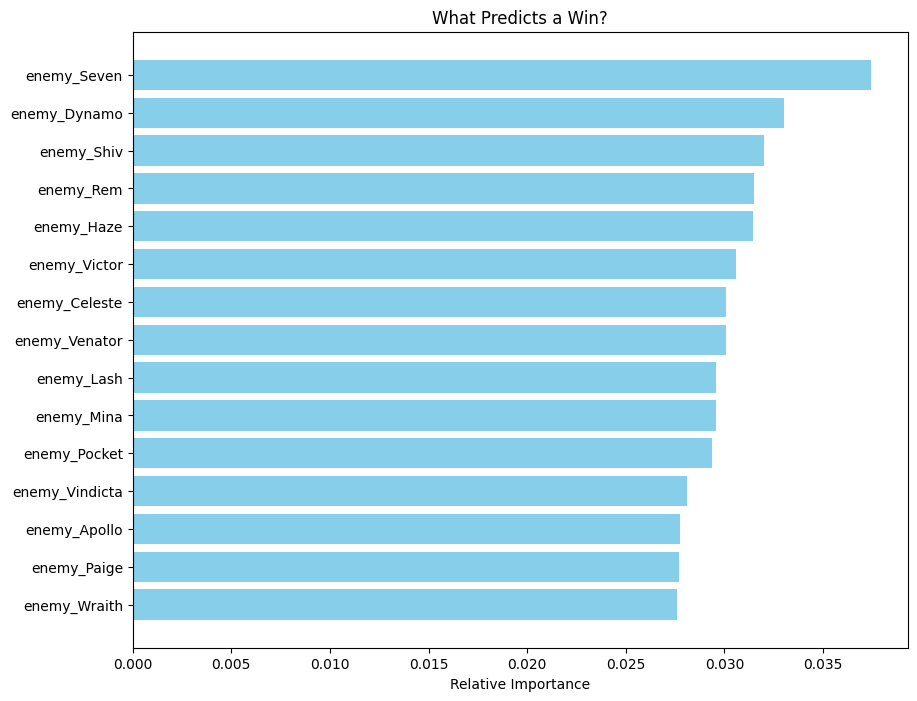

In [184]:
import matplotlib.pyplot as plt
import numpy as np

# Extract importance from the trained model
importances = model.feature_importances_
indices = np.argsort(importances)[-15:] # Take the top 15

plt.figure(figsize=(10, 8))
plt.title("What Predicts a Win?")
plt.barh(range(len(indices)), importances[indices], color='skyblue')
plt.yticks(range(len(indices)), [feature_cols[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

Overall Model Accuracy: 46.67%
------------------------------
Classification Report:
              precision    recall  f1-score   support

        Loss       0.46      0.40      0.43       120
         Win       0.47      0.53      0.50       120

    accuracy                           0.47       240
   macro avg       0.47      0.47      0.46       240
weighted avg       0.47      0.47      0.46       240



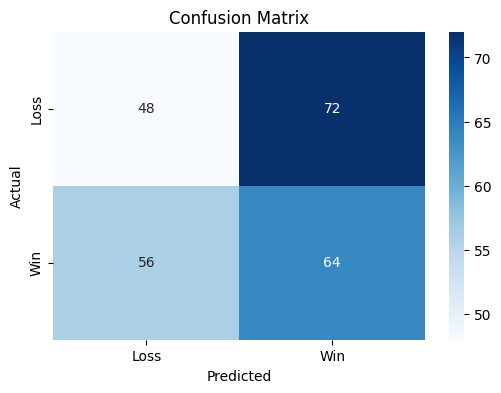

In [185]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

# 1. Generate predictions using the test set
y_pred = model.predict(X_test)

# 2. Print the overall Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Overall Model Accuracy: {accuracy:.2%}")
print("-" * 30)

# 3. Print the Classification Report (Precision, Recall, F1-Score)
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Loss', 'Win']))

# 4. Optional: Visualize a Confusion Matrix to see where the model gets confused
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Loss', 'Win'], yticklabels=['Loss', 'Win'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [186]:
def recommend_counters(model, target_hero, feature_cols):
    results = []

    # Get all strategy columns (the 'has_...' ones)
    strategy_cols = [col for col in feature_cols if col.startswith('has_')]
    enemy_hero_col = f'enemy_{target_hero.replace(" ", "_")}'

    if enemy_hero_col not in feature_cols:
        return "Hero not found in model features."

    for strategy in strategy_cols:
        # Create a "Baseline" match (Enemy has target hero, you have NO counters)
        baseline = pd.DataFrame(0, index=[0], columns=feature_cols)
        baseline[enemy_hero_col] = 1

        # Create an "Intervention" match (Enemy has target hero, you HAVE this counter)
        intervention = baseline.copy()
        intervention[strategy] = 1

        # Get win probabilities (index 1 is the 'Win' probability)
        prob_none = model.predict_proba(baseline)[0][1]
        prob_with = model.predict_proba(intervention)[0][1]

        # Calculate the "Lift" - how much does THIS item help against THIS hero?
        lift = prob_with - prob_none
        results.append({'Strategy': strategy, 'Lift': lift})

    # Sort by the highest lift
    recommendations = pd.DataFrame(results).sort_values(by='Lift', ascending=False)
    return recommendations

# Test it for Silver
silver_recommendations = recommend_counters(model, 'Silver', feature_cols)
print("Best strategies against Silver:")
display(silver_recommendations)

Best strategies against Silver:


,Strategy,Lift
0,has_anti_ability,0.01
8,has_anti_spirit,0.01
1,has_anti_movement,0.00
2,has_anti_heal,0.00
4,has_anti_air_channel,-0.01
3,has_anti_burst,-0.01
6,has_anti_bullet,-0.01
9,has_anti_melee,-0.02
7,has_anti_cc,-0.03
5,has_anti_debuff,-0.04


In [189]:
def get_item_recommendations(model, target_hero, feature_cols, counter_metadata):
    rankings = recommend_counters(model, target_hero, feature_cols)

    # Increase to head(5) so Anti-Bullet has a better chance of appearing
    top_strategies = rankings[rankings['Lift'] > -1].head(3)

    print(f"=== COUNTER GUIDE VS {target_hero.upper()} ===")

    for _, row in top_strategies.iterrows():
        lift = row['Lift']
        strategy_raw = row['Strategy']
        display_name = strategy_raw.replace('has_', '').replace('_', '-').title()

        # Only show if there are items in our metadata for this strategy
        matching_items = [
            {"name": name, "tier": info['tier'], "cost": info['cost']}
            for name, info in counter_metadata.items()
            if info['tag'].lower() == display_name.lower()
        ]

        if not matching_items:
            continue

        print(f"\n[Strategy: {display_name}] (Win Prob Boost: +{lift:.2%})")
        sorted_items = sorted(matching_items, key=lambda x: x['tier'])
        for item in sorted_items:
            print(f"  - Tier {item['tier']} ({item['cost']}s): {item['name']}")

In [197]:
# What items should I buy against [hero]?
# Change the 2nd parameter to any Deadlock hero!
get_item_recommendations(model, 'Wraith', feature_cols, counter_metadata)

=== COUNTER GUIDE VS WRAITH ===

[Strategy: Anti-Cc] (Win Prob Boost: +10.00%)
  - Tier 2 (1600s): Reactive Barrier
  - Tier 4 (6400s): Unstoppable

[Strategy: Anti-Bullet] (Win Prob Boost: +2.00%)
  - Tier 2 (1600s): Return Fire
  - Tier 2 (1600s): Weapon Shielding
  - Tier 3 (3200s): Metal Skin
  - Tier 3 (3200s): Bullet Resilience
  - Tier 3 (3200s): Disarming Hex


##Conclusion and Future Iterations

### Project Summary
This prototype successfully demonstrates a functional pipeline for translating raw MOBA match data into actionable player recommendations. By abstracting 150+ items into strategic categories, the model provides a "Build Path" that scales across different soul-economies (Tiers 2, 3, and 4).

### Analysis of Current Performance
The model's current accuracy of **46.67%** is a baseline reflective of a small-scale dataset (100 matches). In a high-complexity environment like *Deadlock*, where player mechanical skill and team coordination are unobserved variables, a model requires a significantly higher volume of data to separate "item impact" from "player skill."

### Future Engineering Roadmap
To move this from a student project to a production-grade tool, the following iterations are planned:
1. **Dataset Expansion:** Scale data ingestion to 10,000+ matches using a distributed crawler to improve the statistical significance of "Win Probability Lift."
2. **Temporal Weighting:** Implement logic to weight recent patches more heavily, ensuring recommendations adapt to the ever-shifting "meta" of the game.
3. **Advanced Feature Engineering:** * Incorporate **Hero Synergy**: Recommending items based not just on the enemy, but on who is on your own team.
    * **Gold-Delta Analysis**: Adjusting recommendations based on whether the player is currently ahead or behind in net worth.
4. **Deep Learning Implementation:** Transition from Random Forest to a Neural Network (Multi-Layer Perceptron) to better capture complex, non-linear interactions between 12 different hero picks and 60+ active items.

---
